# PenSimPy API Demo

This notebook walks through the API from simplest to most complete.

| Section | What it does |
|---|---|
| 0 | Setup & health check |
| 1 | Full batch, all defaults |
| 2 | Full batch, custom recipe |
| 3 | Full automation run — predictor drives every step |
| 4 | Next N minutes — pause, inspect, resume |

## 0 · Setup

In [5]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'requests', 'pandas', 'matplotlib'])


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


0

In [6]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# When running via docker compose the API is reachable at http://api:8000.
# Change to http://localhost:8000 if you are running the API separately.
BASE = "http://localhost:8000"
STEP_MINUTES = 12

def get(path, **kw):  return requests.get(f"{BASE}{path}", **kw)
def post(path, **kw): return requests.post(f"{BASE}{path}", **kw)

r = get("/")
assert r.status_code == 200, f"API not reachable: {r.text}"
print("API is up:", r.json()["docs"])

API is up: /docs


---
## 1 · Full batch — all defaults

One call, 230 hours, every variable on its default recipe profile.

In [7]:
resp = post("/batch", json={"random_seed": 0})
resp.raise_for_status()
data = resp.json()

df_default = pd.DataFrame(data["data"], index=data["index_hours"])
df_default.index.name = "time_h"
print(f"{len(df_default)} steps  |  columns: {list(df_default.columns)}")
df_default.head()

1150 steps  |  columns: ['Volume', 'Penicillin Concentration', 'Discharge rate', 'Sugar feed rate', 'Soil bean feed rate', 'Aeration rate', 'Back pressure', 'Water injection/dilution', 'Phenylacetic acid flow-rate', 'pH', 'Temperature', 'Acid flow rate', 'Base flow rate', 'Cooling water', 'Heating water', 'Vessel Weight', 'Dissolved oxygen concentration', 'Oxygen in percent in off-gas']


,Volume,Penicillin Concentration,Discharge rate,Sugar feed rate,Soil bean feed rate,Aeration rate,Back pressure,Water injection/dilution,Phenylacetic acid flow-rate,pH,Temperature,Acid flow rate,Base flow rate,Cooling water,Heating water,Vessel Weight,Dissolved oxygen concentration,Oxygen in percent in off-gas
time_h,,,,,,,,,,,,,,,,,,
0.2,58340.623835,0.001000,0,8,22,30,0.6,0,5.0,6.440629,297.672434,0.0,24.301908,0.000100,227.071232,61979.787473,14.734653,0.220721
0.4,58347.762366,0.000999,0,8,22,30,0.6,0,5.0,6.457478,297.883334,0.0,48.050249,0.000100,65.513215,61991.530680,14.720482,0.209954
0.6,58358.455066,0.000999,0,8,22,30,0.6,0,5.0,6.486553,297.859096,0.0,65.523973,0.000100,0.000100,62006.834485,14.709695,0.207437
0.8,58370.307836,0.000998,0,8,22,30,0.6,0,5.0,6.522184,298.153474,0.0,71.381269,0.000100,88.176813,62023.313140,14.706325,0.206859
1.0,58380.411393,0.000997,0,8,22,30,0.6,0,5.0,6.554319,298.070479,0.0,63.003913,96.458307,8.817681,62038.054810,14.699069,0.206703


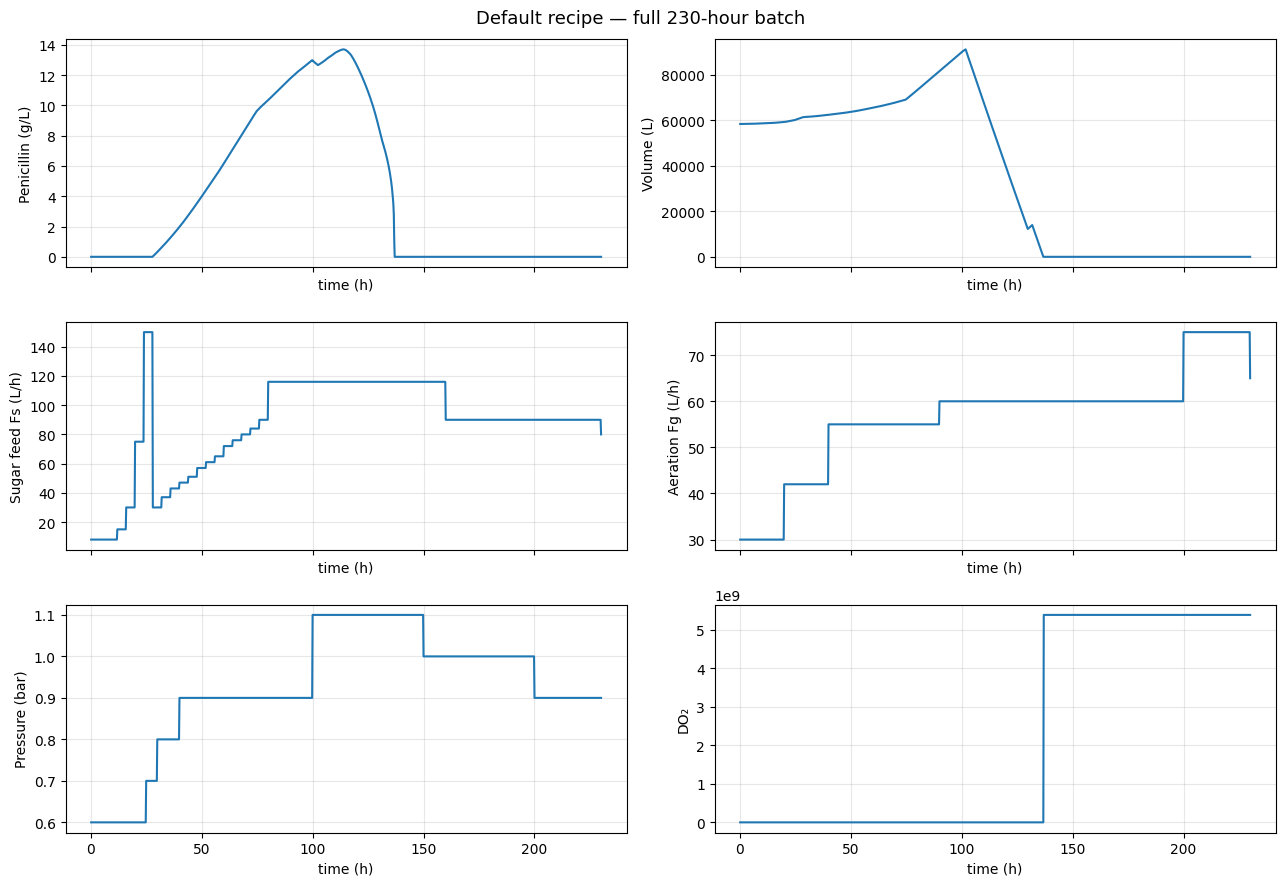

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(13, 9), sharex=True)
pairs = [
    ("Penicillin Concentration", "Penicillin (g/L)"),
    ("Volume",                   "Volume (L)"),
    ("Sugar feed rate",          "Sugar feed Fs (L/h)"),
    ("Aeration rate",            "Aeration Fg (L/h)"),
    ("Back pressure",            "Pressure (bar)"),
    ("Dissolved oxygen concentration", "DO₂"),
]
for ax, (col, label) in zip(axes.flat, pairs):
    ax.plot(df_default.index, df_default[col])
    ax.set_ylabel(label)
    ax.set_xlabel("time (h)")
    ax.grid(True, alpha=0.3)
fig.suptitle("Default recipe — full 230-hour batch", fontsize=13)
fig.tight_layout()
plt.show()

---
## 2 · Full batch — custom recipe

Override only the variables you care about. Everything else stays on the default profile.

- **`Fs`** (sugar feed): starts low (20 L/h), ramps to 80 L/h at hour 50, drops to 50 L/h at hour 150  
- **`Fg`** (aeration): starts at 45 L/h, increases to 65 L/h at hour 100  
- **`pressure`**: fixed at 0.8 bar for the whole batch  

In [9]:
custom_recipe = {
    "Fs": [
        {"time": 0,   "value": 20},
        {"time": 50,  "value": 80},
        {"time": 150, "value": 50},
    ],
    "Fg": [
        {"time": 0,   "value": 45},
        {"time": 100, "value": 65},
    ],
    "pressure": [
        {"time": 0, "value": 0.8},
    ],
}

resp = post("/batch", json={"random_seed": 0, "recipe": custom_recipe})
resp.raise_for_status()
data = resp.json()

df_custom = pd.DataFrame(data["data"], index=data["index_hours"])
df_custom.index.name = "time_h"
print(f"Done — {len(df_custom)} steps")

Done — 1150 steps


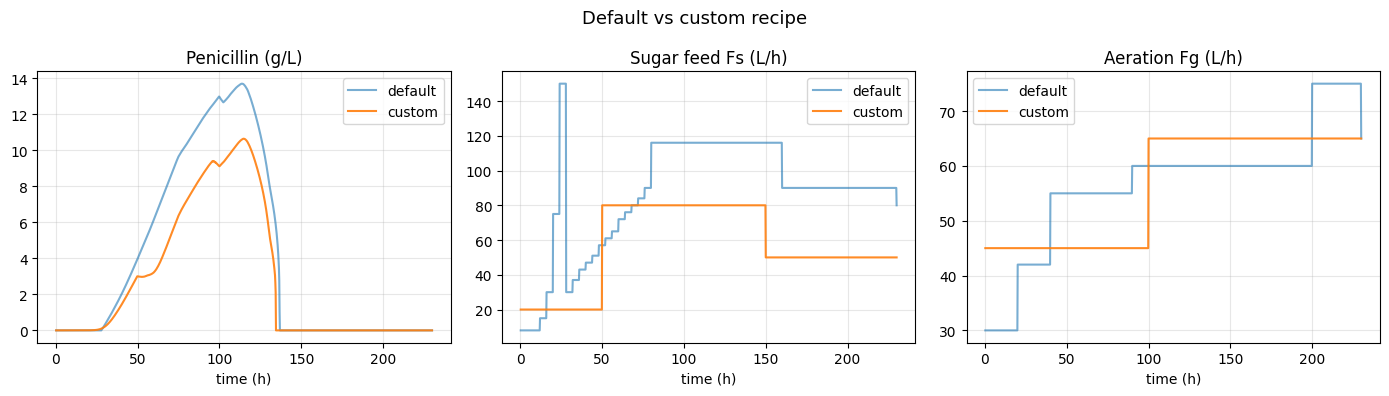

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for col, ax, title in [
    ("Penicillin Concentration", axes[0], "Penicillin (g/L)"),
    ("Sugar feed rate",          axes[1], "Sugar feed Fs (L/h)"),
    ("Aeration rate",            axes[2], "Aeration Fg (L/h)"),
]:
    ax.plot(df_default.index, df_default[col], label="default", alpha=0.6)
    ax.plot(df_custom.index,  df_custom[col],  label="custom",  alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel("time (h)")
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle("Default vs custom recipe", fontsize=13)
fig.tight_layout()
plt.show()

---
## 3 · Full automation run — predictor drives every step

Create a session and call `/step` 1 150 times. A simple rule-based predictor
adjusts `Fs` based on current penicillin concentration.  
Replace `predictor()` with your own model.

In [11]:
def predictor(obs: dict) -> dict:
    """
    Example rule-based controller.
    Returns only the variables to override; the rest follow the recipe.
    """
    pen  = obs["penicillin"]
    do2  = obs["dissolved_O2"]
    ph   = obs["pH"]

    # Boost sugar feed when penicillin production is low
    if pen < 0.1:
        Fs = 90.0
    elif pen < 0.5:
        Fs = 60.0
    else:
        Fs = 40.0

    # Increase aeration when dissolved O2 drops
    Fg = max(30.0, min(75.0, 55.0 - (do2 - 10.0) * 0.5))

    return {"Fs": Fs, "Fg": Fg}
    # Omitted variables (Foil, pressure, discharge, Fw, Fpaa) follow the recipe

In [12]:
# Create session
session = post("/sessions", json={"random_seed": 0}).json()
sid = session["session_id"]
obs = session["observation"]
print(f"Session {sid}  |  step 0, pH={obs['pH']:.2f}")

# Run to completion
history = []
while not obs["done"]:
    action = predictor(obs)
    obs = post(f"/sessions/{sid}/step", json=action).json()
    history.append(obs)

print(f"\nFinished at step {obs['step']}  |  total yield: {obs['total_yield']:.2f}")

Session 47376c44-6726-4cbe-ad7d-24d04245081f  |  step 0, pH=0.00

Finished at step 1150  |  total yield: 1282.34


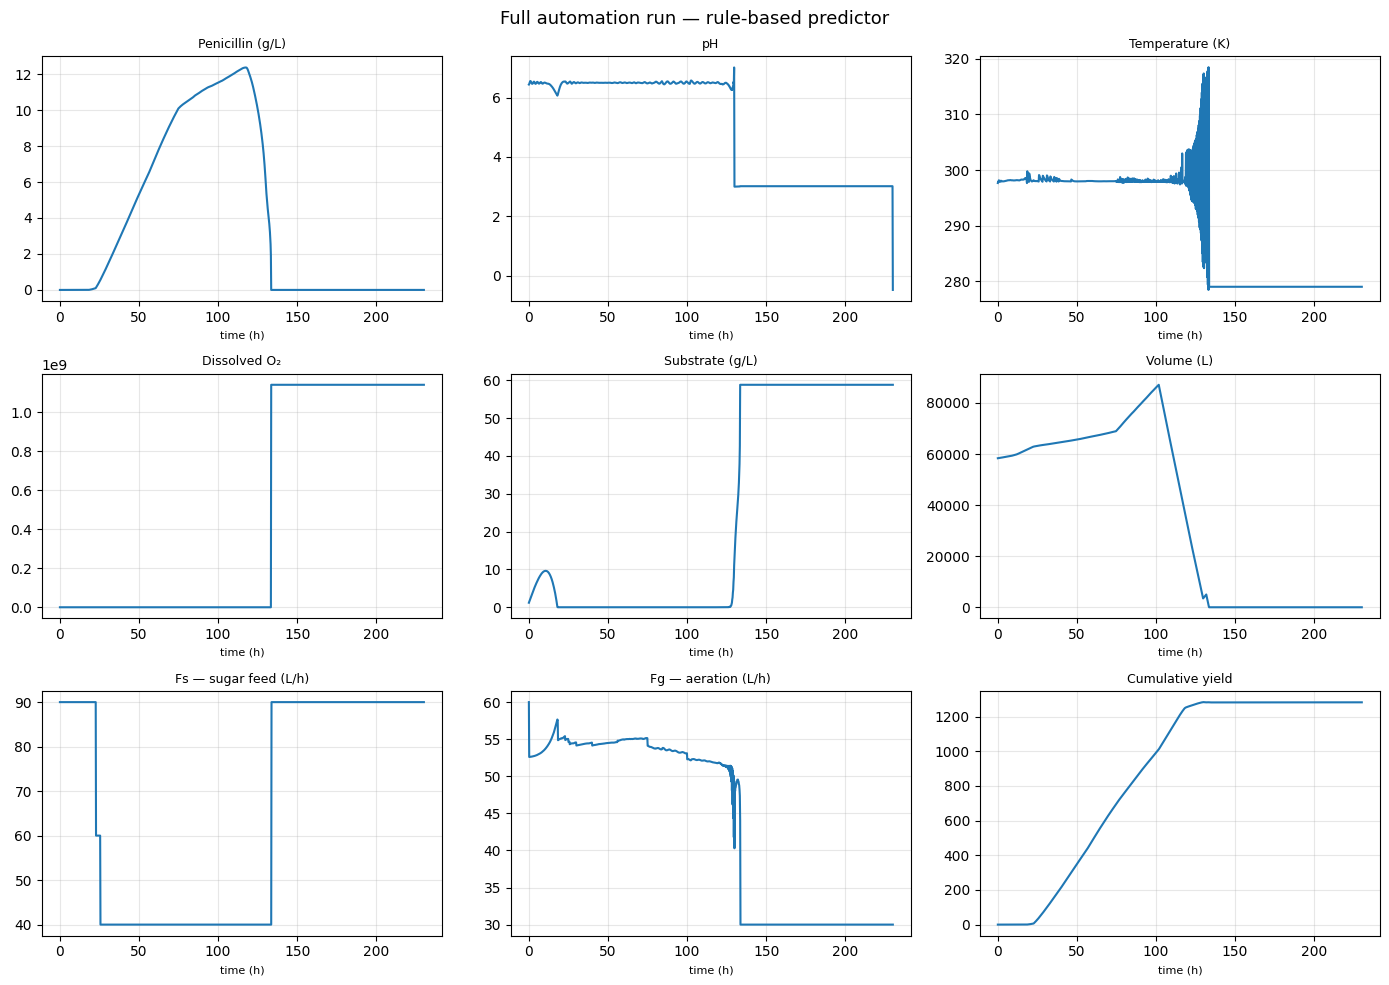

In [13]:
df_auto = pd.DataFrame(history).set_index("time_hours")

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 3, figure=fig)

plot_cols = [
    ("penicillin",   "Penicillin (g/L)"),
    ("pH",           "pH"),
    ("temperature",  "Temperature (K)"),
    ("dissolved_O2", "Dissolved O₂"),
    ("substrate",    "Substrate (g/L)"),
    ("volume",       "Volume (L)"),
    ("Fs",           "Fs — sugar feed (L/h)"),
    ("Fg",           "Fg — aeration (L/h)"),
    ("total_yield",  "Cumulative yield"),
]
for i, (col, label) in enumerate(plot_cols):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    ax.plot(df_auto.index, df_auto[col])
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("time (h)", fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Full automation run — rule-based predictor", fontsize=13)
fig.tight_layout()
plt.show()

---
## 4 · Next N minutes — pause, inspect, resume

The session persists between calls. You can advance any number of minutes,
stop to inspect or call your model, then continue.

In [14]:
def advance_minutes(sid: str, minutes: int, action: dict = None) -> list:
    """Advance the simulation by `minutes` and return the list of observations."""
    steps  = round(minutes / STEP_MINUTES)
    result = []
    for _ in range(steps):
        obs = post(f"/sessions/{sid}/step", json=action or {}).json()
        result.append(obs)
        if obs["done"]:
            break
    return result

In [15]:
# Fresh session
sid = post("/sessions", json={"random_seed": 7}).json()["session_id"]
print(f"Session: {sid}")

# ── Phase 1: first 48 hours on default recipe ─────────────────────────────
batch1 = advance_minutes(sid, 48 * 60)
s1 = batch1[-1]
print(f"\nAfter 48 h  →  step {s1['step']:4d} | "
      f"pen={s1['penicillin']:.4f} g/L | "
      f"pH={s1['pH']:.2f} | "
      f"DO₂={s1['dissolved_O2']:.1f}")

Session: d8db6f9c-840e-4ded-b915-a0c5f157d908

After 48 h  →  step  240 | pen=3.6410 g/L | pH=6.50 | DO₂=11.9


In [16]:
# Inspect current state without stepping
state = requests.get(f"{BASE}/sessions/{sid}/state").json()
print("Current state")
for k, v in state.items():
    print(f"  {k:20s}: {v}")

Current state
  step                : 240
  time_hours          : 48.0
  done                : False
  yield_delta         : 0.0
  total_yield         : 232.836902
  pH                  : 6.504
  temperature         : 298.0381
  dissolved_O2        : 11.894
  substrate           : 0.002107
  penicillin          : 3.64095
  volume              : 63949.49
  vessel_weight       : 69321.03
  O2_offgas           : 0.190718
  CO2_offgas          : 1.165006
  Fs                  : 57.0
  Foil                : 30.0
  Fg                  : 55.0
  pressure            : 0.9
  discharge           : 0.0
  Fw                  : 0.0
  Fpaa                : 6.5771
  Fa                  : 0.0
  Fb                  : 114.7366
  Fc                  : 84.6607
  Fh                  : 0.0001


In [17]:
# ── Phase 2: next 60 minutes with elevated Fs ─────────────────────────────
batch2 = advance_minutes(sid, 60, action={"Fs": 120.0, "Fg": 65.0})
s2 = batch2[-1]
print(f"After 49 h  →  step {s2['step']:4d} | "
      f"pen={s2['penicillin']:.4f} g/L | "
      f"Fs applied={s2['Fs']:.1f} L/h")

After 49 h  →  step  245 | pen=3.6275 g/L | Fs applied=120.0 L/h


In [18]:
# ── Phase 3: run remaining hours to completion ─────────────────────────────
batch3 = []
obs    = {"done": False}
while not obs["done"]:
    chunk = advance_minutes(sid, 60)   # one hour at a time, default recipe
    batch3.extend(chunk)
    obs = chunk[-1]
    print(f"  → {obs['time_hours']:6.1f} h | "
          f"pen={obs['penicillin']:.4f} | "
          f"yield so far={obs['total_yield']:.2f}")

print(f"\nDone. Final yield: {obs['total_yield']:.2f}")

  →   50.0 h | pen=3.8425 | yield so far=247.56
  →   51.0 h | pen=4.0625 | yield so far=262.48
  →   52.0 h | pen=4.2877 | yield so far=277.63
  →   53.0 h | pen=4.5147 | yield so far=293.19
  →   54.0 h | pen=4.7441 | yield so far=309.02
  →   55.0 h | pen=4.9799 | yield so far=325.17
  →   56.0 h | pen=5.2175 | yield so far=341.52
  →   57.0 h | pen=5.4526 | yield so far=358.00
  →   58.0 h | pen=5.6868 | yield so far=374.70
  →   59.0 h | pen=5.9247 | yield so far=391.69
  →   60.0 h | pen=6.1695 | yield so far=409.11
  →   61.0 h | pen=6.4173 | yield so far=426.83
  →   62.0 h | pen=6.6665 | yield so far=444.86
  →   63.0 h | pen=6.9149 | yield so far=462.99
  →   64.0 h | pen=7.1664 | yield so far=481.44
  →   65.0 h | pen=7.4205 | yield so far=500.16
  →   66.0 h | pen=7.6742 | yield so far=519.00
  →   67.0 h | pen=7.9275 | yield so far=537.98
  →   68.0 h | pen=8.1765 | yield so far=556.82
  →   69.0 h | pen=8.4239 | yield so far=575.78
  →   70.0 h | pen=8.6670 | yield so far

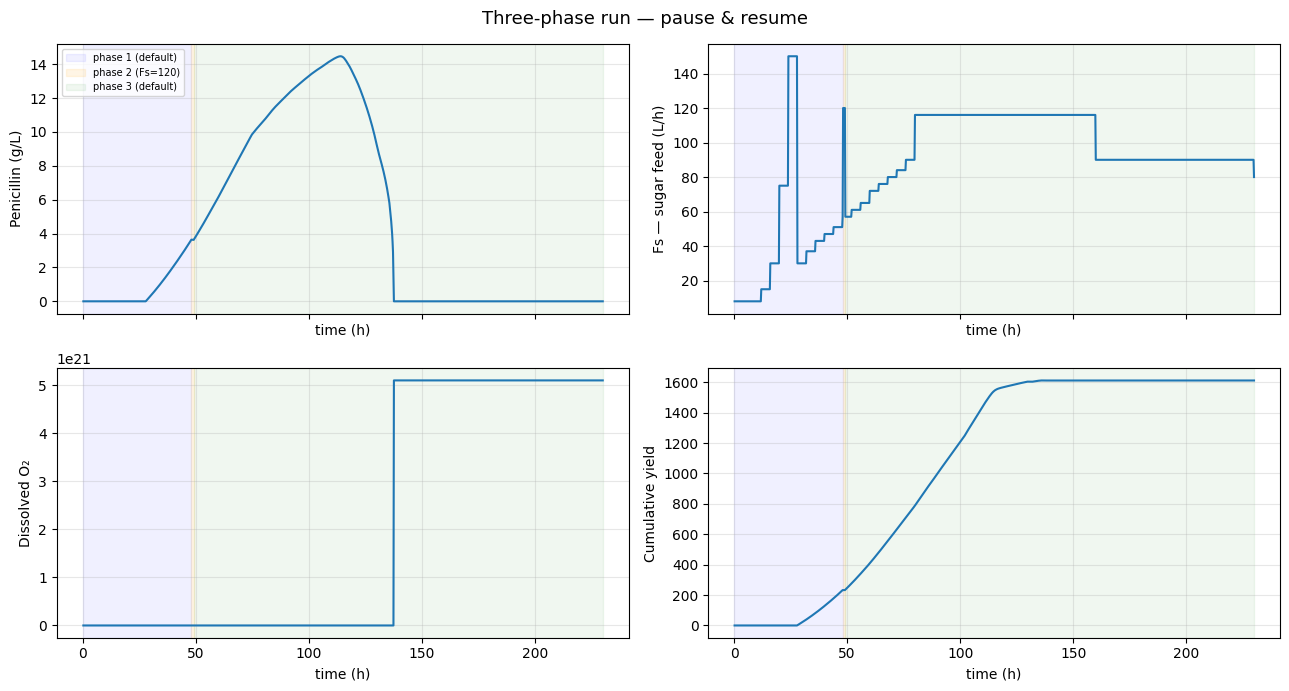

In [19]:
# Plot the three phases together
all_obs = batch1 + batch2 + batch3
df_phased = pd.DataFrame(all_obs).set_index("time_hours")

fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)

# Shade the three phases
t1_end = batch1[-1]["time_hours"]
t2_end = batch2[-1]["time_hours"]

for ax in axes.flat:
    ax.axvspan(0,      t1_end, alpha=0.06, color="blue",  label="phase 1 (default)")
    ax.axvspan(t1_end, t2_end, alpha=0.10, color="orange", label="phase 2 (Fs=120)")
    ax.axvspan(t2_end, 230,    alpha=0.06, color="green",  label="phase 3 (default)")

for ax, (col, label) in zip(axes.flat, [
    ("penicillin",  "Penicillin (g/L)"),
    ("Fs",          "Fs — sugar feed (L/h)"),
    ("dissolved_O2","Dissolved O₂"),
    ("total_yield", "Cumulative yield"),
]):
    ax.plot(df_phased.index, df_phased[col], zorder=3)
    ax.set_ylabel(label)
    ax.set_xlabel("time (h)")
    ax.grid(True, alpha=0.3)

axes[0, 0].legend(fontsize=7, loc="upper left")
fig.suptitle("Three-phase run — pause & resume", fontsize=13)
fig.tight_layout()
plt.show()